# Model Performance Analysis
Analyze screening accuracy and fit statistics from Promptfoo evaluation results.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Set Seaborn theme once
sns.set_theme(style="ticks")

# Add tools/py to path to import helpers
sys.path.append(str(Path.cwd().parents[1]))
from helpers.promptfoo_helper import PromptfooCsvCols  # noqa: E402

# Import globals from run.py
sys.path.append(str(Path.cwd()))
from run import TMP_DIR  # noqa: E402

csv_files = sorted(TMP_DIR.glob("eval_results_for_*_models.csv"), key=lambda p: p.stat().st_mtime, reverse=True)
results_path = csv_files[0]

df = pd.read_csv(results_path)

# Define consistent color palette for models dynamically supporting any number of models
unique_models = sorted(df[PromptfooCsvCols.PROVIDER_ID].unique())
base_colors = sns.color_palette("muted", len(unique_models)).as_hex()
model_palette = {model: base_colors[i] for i, model in enumerate(unique_models)}

df.head(10)

,Provider Id,Provider Label,Prompt Label,Success,Score,Passed,Failed,Latency (s),Prompt Tokens,Completion Tokens,Total Tokens,Failure Reason
0,google:gemini-3.5-flash,NaN,file://contract_prompt.txt,FAIL,0,0,0,0.955,0,0,0,2.0
1,google:gemma-4-31b-it,NaN,file://contract_prompt.txt,FAIL,0,0,0,0.774,0,0,0,2.0
2,google:gemini-3.1-flash-lite,NaN,file://contract_prompt.txt,PASS,1,1,0,2.030,2522,320,2842,NaN
3,google:gemma-4-26b-a4b-it,NaN,file://contract_prompt.txt,PASS,1,1,0,33.780,2522,285,4022,NaN
4,google:gemini-3.5-flash,NaN,file://intern_prompt.txt,FAIL,0,0,0,0.843,0,0,0,2.0
5,google:gemini-3.1-flash-lite,NaN,file://intern_prompt.txt,PASS,1,1,0,1.787,2770,286,3056,NaN
6,google:gemma-4-26b-a4b-it,NaN,file://intern_prompt.txt,PASS,1,1,0,60.146,2770,206,5506,NaN
7,google:gemma-4-31b-it,NaN,file://intern_prompt.txt,PASS,1,1,0,45.328,2770,286,4346,NaN
8,google:gemma-4-31b-it,NaN,file://manager_prompt.txt,FAIL,0,0,0,0.363,0,0,0,2.0
9,google:gemini-3.1-flash-lite,NaN,file://manager_prompt.txt,PASS,1,1,0,1.500,2803,222,3025,NaN


In [2]:
# Generate summary table: Pass, Fail, Total, Success Rate (%)
summary = (
    df.groupby(PromptfooCsvCols.PROVIDER_ID)[PromptfooCsvCols.SUCCESS].value_counts().unstack().fillna(0).astype(int)  # noqa: PD010
)
if "PASS" not in summary.columns:
    summary["PASS"] = 0
if "FAIL" not in summary.columns:
    summary["FAIL"] = 0

summary["Total"] = summary["PASS"] + summary["FAIL"]
summary["Success Rate (%)"] = (summary["PASS"] / summary["Total"] * 100).round(1)

# Reorder columns for clean presentation
summary = summary[["PASS", "FAIL", "Total", "Success Rate (%)"]].sort_values(["Success Rate (%)"])
display(summary)

Success,PASS,FAIL,Total,Success Rate (%)
Provider Id,,,,
google:gemini-3.5-flash,3,5,8,37.5
google:gemma-4-31b-it,6,2,8,75.0
google:gemini-3.1-flash-lite,8,0,8,100.0
google:gemma-4-26b-a4b-it,8,0,8,100.0


## Model Screening Results


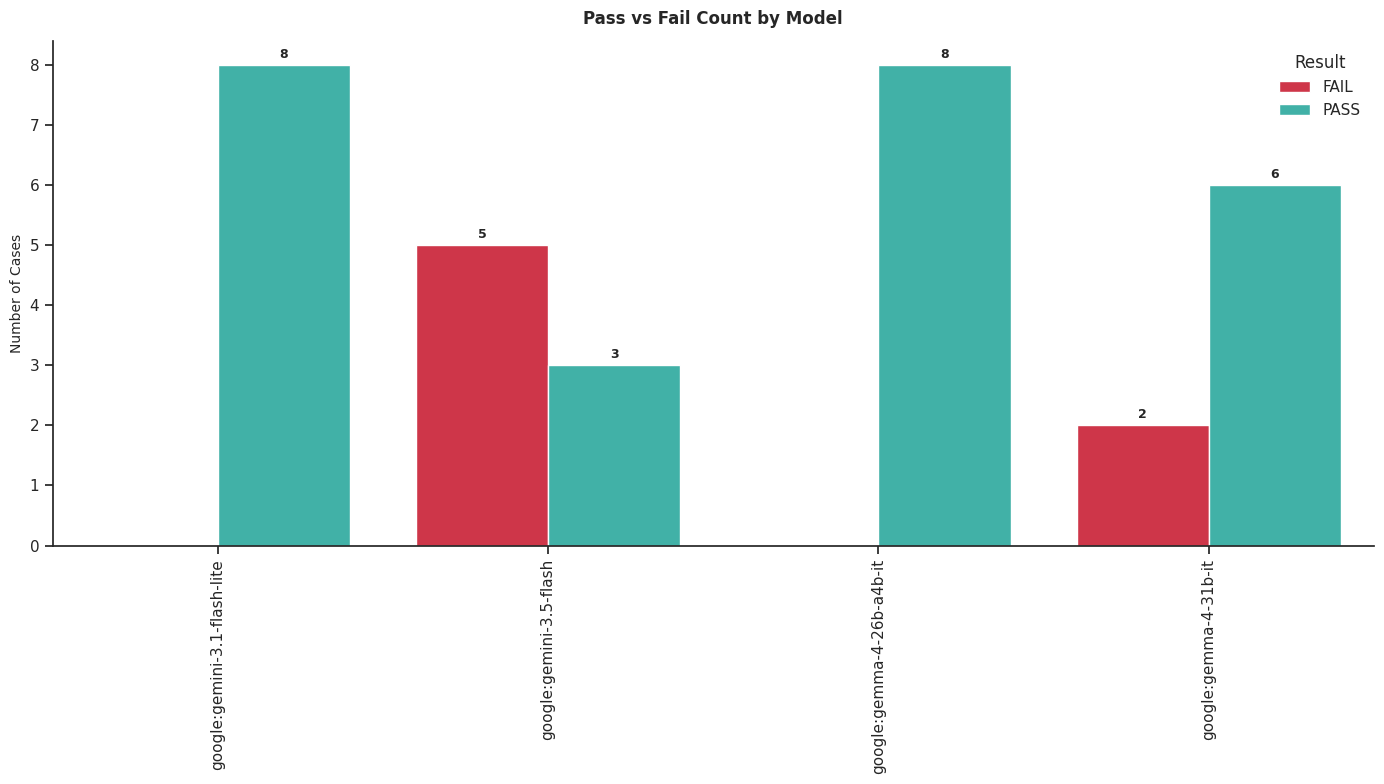

In [3]:
# Plot pass vs fail using Seaborn countplot
plt.figure(figsize=(14, 8))
ax = sns.countplot(
    data=df,
    x=PromptfooCsvCols.PROVIDER_ID,
    order=unique_models,
    hue=PromptfooCsvCols.SUCCESS,
    palette={"PASS": "#2ec4b6", "FAIL": "#e71d36"},
)

plt.title("Pass vs Fail Count by Model", fontsize=12, fontweight="bold", pad=12)
plt.xlabel("")
plt.ylabel("Number of Cases", fontsize=10)
plt.xticks(rotation=90, ha="center")
plt.legend(title="Result", frameon=False, loc="upper right")
sns.despine()

# Add value labels on top of the bars
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(
            f"{int(height)}",
            xy=(p.get_x() + p.get_width() / 2, height),
            xytext=(0, 3),  # 3 points vertical offset
            textcoords="offset points",
            ha="center",
            va="bottom",
            fontsize=9,
            fontweight="bold",
        )

plt.tight_layout()
plt.show()

## Completion Tokens per Job Description


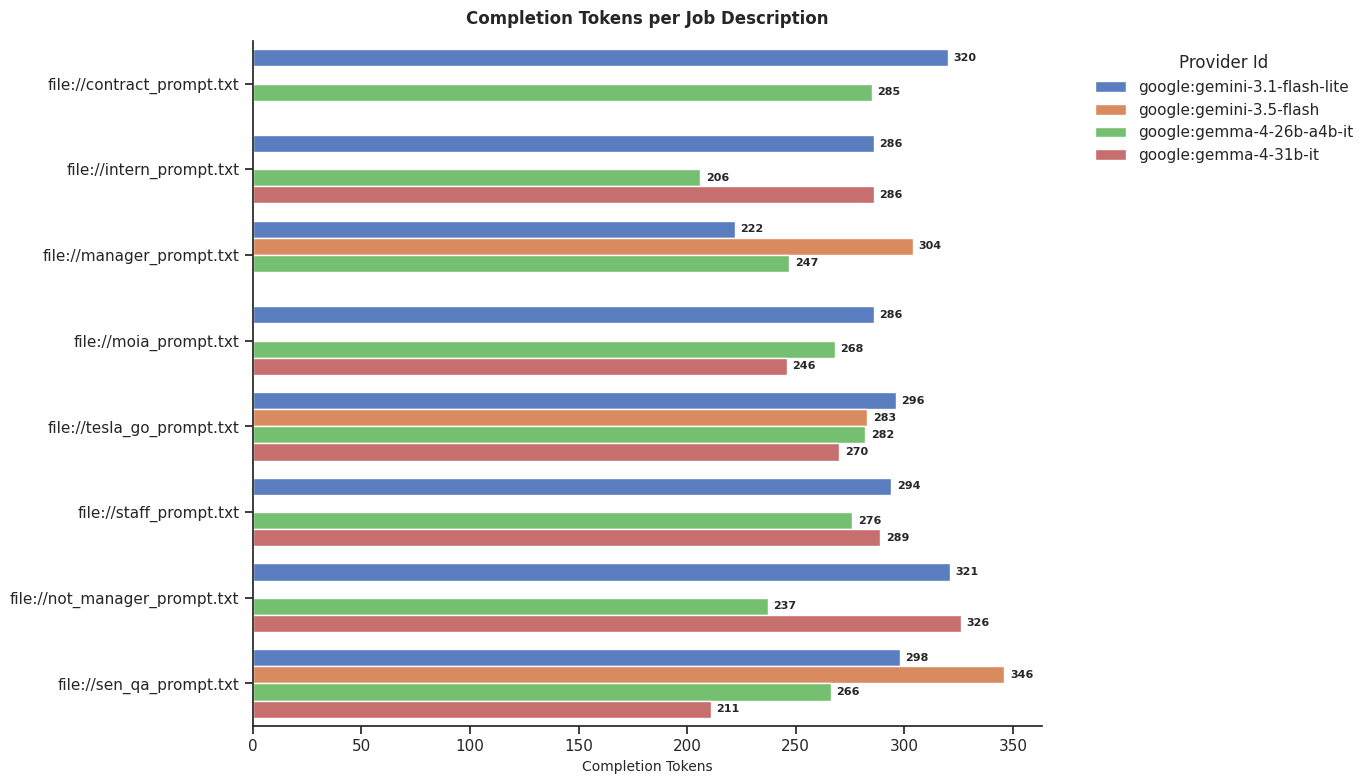

In [4]:
# Plot Completion Tokens per Job Description (Horizontal Bar Chart)
plt.figure(figsize=(14, 8))
ax = sns.barplot(
    data=df,
    y=PromptfooCsvCols.PROMPT_LABEL,
    x=PromptfooCsvCols.COMPLETION_TOKENS,
    hue=PromptfooCsvCols.PROVIDER_ID,
    hue_order=unique_models,
    palette=model_palette,
)
plt.title(f"{PromptfooCsvCols.COMPLETION_TOKENS} per Job Description", fontsize=12, fontweight="bold", pad=12)
plt.xlabel(PromptfooCsvCols.COMPLETION_TOKENS, fontsize=10)
plt.ylabel("")
plt.legend(title=PromptfooCsvCols.PROVIDER_ID, bbox_to_anchor=(1.05, 1), loc="upper left", frameon=False)
sns.despine()

# Add value labels at the end of the bars
for p in ax.patches:
    width = p.get_width()
    if width > 0:
        ax.annotate(
            f"{int(width)}",
            xy=(width, p.get_y() + p.get_height() / 2),
            xytext=(4, 0),  # 4 points horizontal offset
            textcoords="offset points",
            ha="left",
            va="center",
            fontsize=8,
            fontweight="bold",
        )

plt.tight_layout()
plt.show()

## Average Completion Tokens by Model


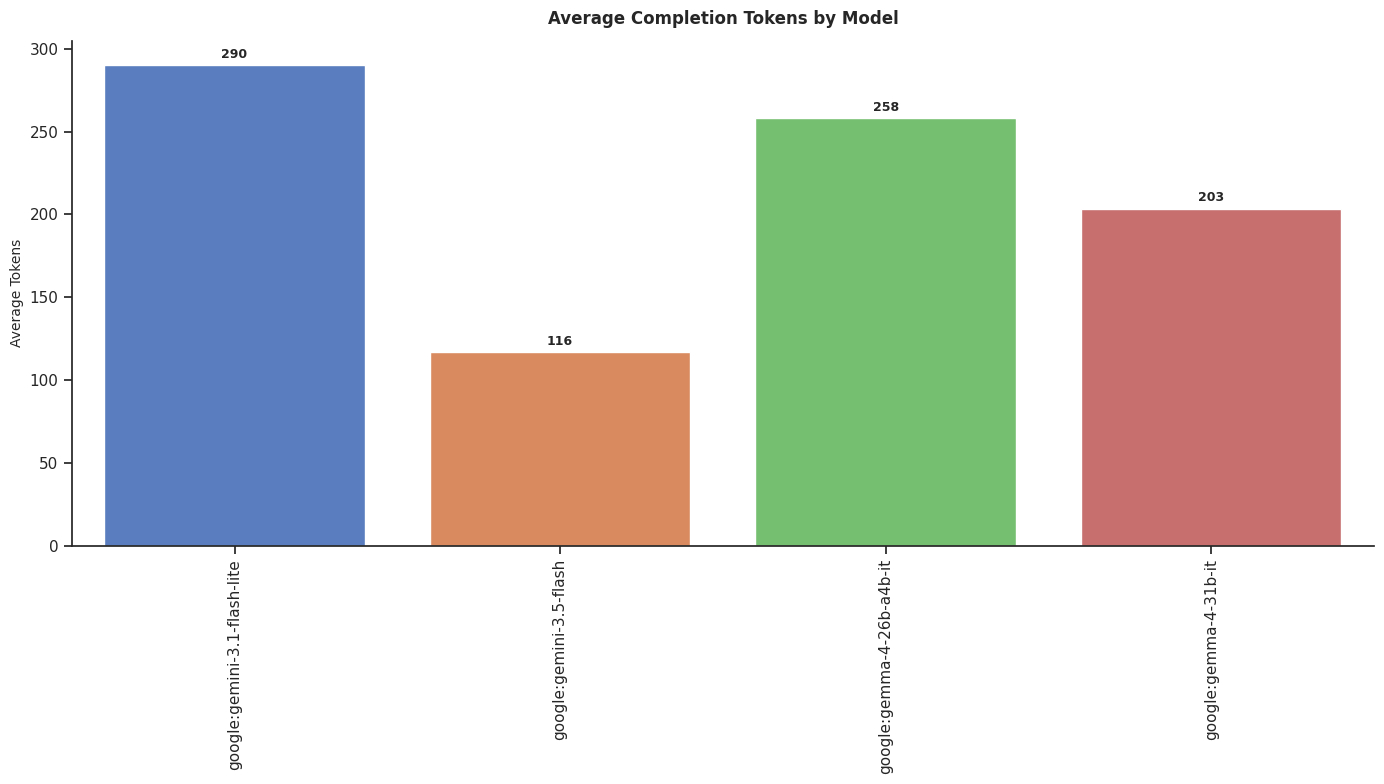

In [5]:
# Plot Average Completion Tokens by Model
plt.figure(figsize=(14, 8))
ax = sns.barplot(
    data=df,
    x=PromptfooCsvCols.PROVIDER_ID,
    y=PromptfooCsvCols.COMPLETION_TOKENS,
    hue=PromptfooCsvCols.PROVIDER_ID,
    order=unique_models,
    hue_order=unique_models,
    palette=model_palette,
    legend=False,
    estimator="mean",
    errorbar=None,
)
plt.title(f"Average {PromptfooCsvCols.COMPLETION_TOKENS} by Model", fontsize=12, fontweight="bold", pad=12)
plt.xlabel("")
plt.ylabel("Average Tokens", fontsize=10)
plt.xticks(rotation=90, ha="center")
sns.despine()

# Add labels on top of the bars
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(
            f"{int(height)}",
            xy=(p.get_x() + p.get_width() / 2, height),
            xytext=(0, 3),
            textcoords="offset points",
            ha="center",
            va="bottom",
            fontsize=9,
            fontweight="bold",
        )

plt.tight_layout()
plt.show()

## Completion Tokens per Model


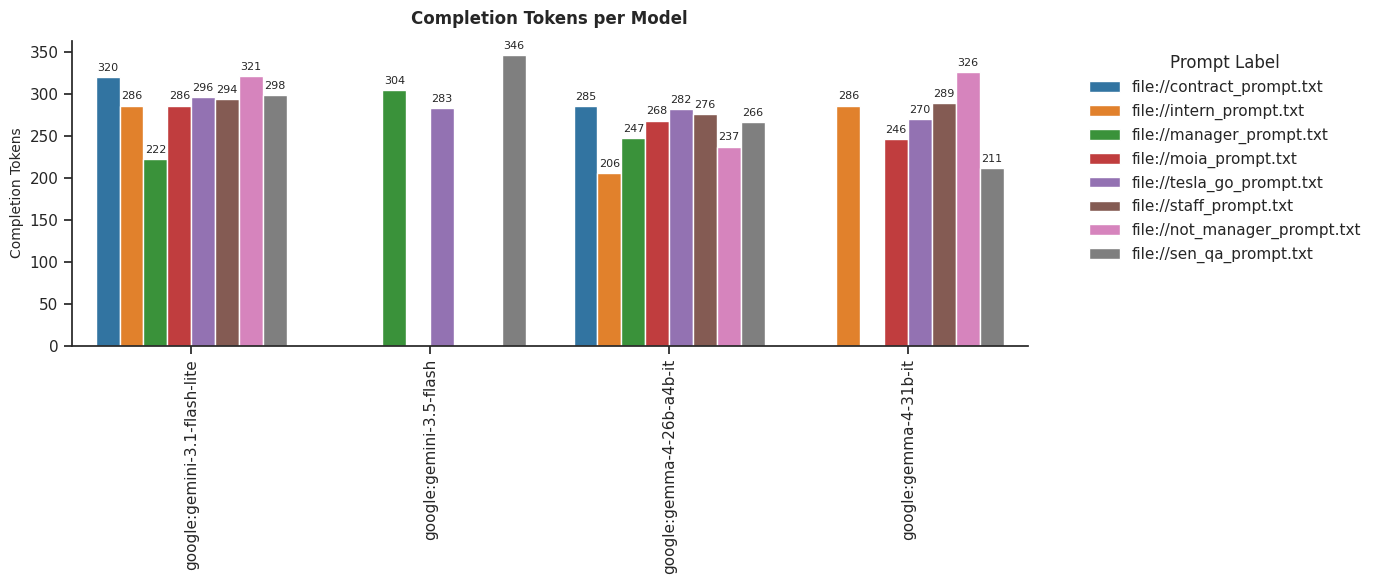

In [6]:
# Plot Completion Tokens per Model
plt.figure(figsize=(14, 6))
ax = sns.barplot(
    data=df,
    x=PromptfooCsvCols.PROVIDER_ID,
    y=PromptfooCsvCols.COMPLETION_TOKENS,
    order=unique_models,
    hue=PromptfooCsvCols.PROMPT_LABEL,
    palette="tab10",
    errorbar=None,
)
plt.title(f"{PromptfooCsvCols.COMPLETION_TOKENS} per Model", fontsize=12, fontweight="bold", pad=12)
plt.xlabel("")
plt.ylabel(PromptfooCsvCols.COMPLETION_TOKENS, fontsize=10)
plt.xticks(rotation=90, ha="center")
plt.legend(title=PromptfooCsvCols.PROMPT_LABEL, bbox_to_anchor=(1.05, 1), loc="upper left", frameon=False)
sns.despine()

# Add value labels on top of the bars
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(
            f"{int(height)}",
            xy=(p.get_x() + p.get_width() / 2, height),
            xytext=(0, 3),
            textcoords="offset points",
            ha="center",
            va="bottom",
            fontsize=8,
        )

plt.tight_layout()
plt.show()

## Average Latency for PASSED Cases


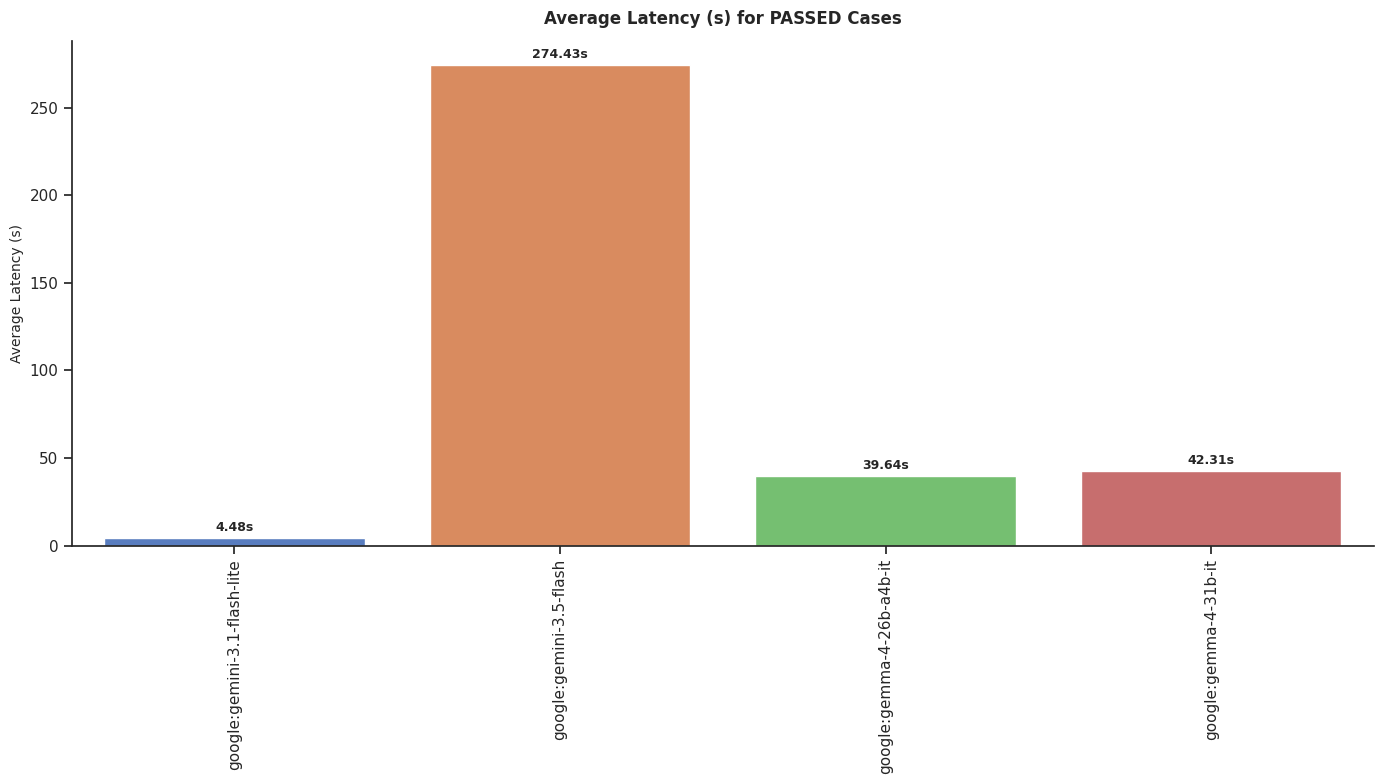

In [7]:
# Filter to only PASSED cases
passed_df = df[df[PromptfooCsvCols.SUCCESS] == "PASS"]

plt.figure(figsize=(14, 8))
if not passed_df.empty:
    ax = sns.barplot(
        data=passed_df,
        x=PromptfooCsvCols.PROVIDER_ID,
        order=unique_models,
        hue_order=unique_models,
        y=PromptfooCsvCols.LATENCY,
        hue=PromptfooCsvCols.PROVIDER_ID,
        palette=model_palette,
        legend=False,
        estimator="mean",
        errorbar=None,
    )
    plt.title(f"Average {PromptfooCsvCols.LATENCY} for PASSED Cases", fontsize=12, fontweight="bold", pad=12)
    plt.xlabel("")
    plt.ylabel(f"Average {PromptfooCsvCols.LATENCY}", fontsize=10)
    plt.xticks(rotation=90, ha="center")
    sns.despine()

    # Add value labels on top of the bars
    for p in ax.patches:
        height = p.get_height()
        if height > 0:
            ax.annotate(
                f"{height:.2f}s",
                xy=(p.get_x() + p.get_width() / 2, height),
                xytext=(0, 3),
                textcoords="offset points",
                ha="center",
                va="bottom",
                fontsize=9,
                fontweight="bold",
            )
else:
    plt.text(
        0.5,
        0.5,
        "No PASSED cases found to calculate latency.",
        horizontalalignment="center",
        verticalalignment="center",
        fontsize=10,
    )
    plt.title(f"Average {PromptfooCsvCols.LATENCY} for PASSED Cases (No Data)", fontsize=12, fontweight="bold", pad=12)
    sns.despine()

plt.tight_layout()
plt.show()

# Print model performance analysis table for Success Rate >= 50%


In [8]:
avg_tokens_col = f"Average {PromptfooCsvCols.COMPLETION_TOKENS}"
avg_latency_col = f"Average {PromptfooCsvCols.LATENCY}"

avg_tokens = df.groupby(PromptfooCsvCols.PROVIDER_ID)[PromptfooCsvCols.COMPLETION_TOKENS].mean().round(1)
avg_latency = passed_df.groupby(PromptfooCsvCols.PROVIDER_ID)[PromptfooCsvCols.LATENCY].mean().round(2)

analysis_tbl = summary.copy()
analysis_tbl[avg_tokens_col] = avg_tokens
analysis_tbl[avg_latency_col] = avg_latency

# Filter and sort
MIN_SUCCESS_RATE = 50
filtered_tbl = analysis_tbl[analysis_tbl["Success Rate (%)"] >= MIN_SUCCESS_RATE]
filtered_tbl = filtered_tbl.sort_values("Success Rate (%)", ascending=False)
styled_df = filtered_tbl.style.background_gradient(
    cmap="RdYlGn", subset=["Success Rate (%)", avg_tokens_col]
).background_gradient(cmap="RdYlGn_r", subset=[avg_latency_col])
display(styled_df)

Success,PASS,FAIL,Total,Success Rate (%),Average Completion Tokens,Average Latency (s)
Provider Id,,,,,,
google:gemini-3.1-flash-lite,8,0,8,100.000000,290.400000,4.480000
google:gemma-4-26b-a4b-it,8,0,8,100.000000,258.400000,39.640000
google:gemma-4-31b-it,6,2,8,75.000000,203.500000,42.310000
